Ice Nucleation Analysis notebook

This notebook produces:

Ice Nucleation Active Site Density ($n_s(T)$): Calculated using the formula:$$n_s(T) = \frac{-\ln(1 - F(T))}{A}$$Where $A$ is the surface area of ice nucleating material per droplet.

Confidence Intervals: 95% CIs for $F$ and $n_s(T)$ calculated using the Log-Log method.

Log-Rank Tests: Pairwise statistical comparison between different sample groups.

Input .csv should be formatted as columns of freezing temperatures headed by an experiment name. The code should be able to do an arbitrary number of experiments at once. 

In [6]:
# libraries - make sure you have all these! 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
import itertools
import os

# Render plots inline
%matplotlib inline

In [7]:
# --- CONFIGURATION ---
# Set the input filename (upload your CSV to the notebook folder)
INPUT_FILENAME = 'Daily_data.csv' 

# Set the Output filename
OUTPUT_FILENAME = 'Daily_data_out_11.csv'

# Surface Area parameter 'A' for ns(T) calculation.
# ns(T) will be calculated in 1/the units you use here. So if your surface area is 1 cm**2 per droplet your ns(T) will be in cm**-2

SURFACE_AREA = 1

# Z score should be 1.96 for a 95% confidence interval and 1.64 for a 90% confidence interval
z_score = 1.96

In [12]:
def survival_cis(S, N, z=1.96):
    #equation 5

    log_log_se= np.sqrt((1-S) / (N * S * np.log(S) ** 2))

    exponent_term = z_score * log_log_se

    return S ** np.exp(exponent_term), S ** np.exp(-exponent_term)

In [13]:
# Calculates Kaplan-Meier stats, Log-Log Confidence Intervals,  and ns(T) values for a single series of temperatures.

def calculate_km_loglog(series, group_name):
    """
    inputs: series (pandas dataframe)
    """

    # Clean and Sort
    series = pd.to_numeric(series, errors='coerce')
    temps = series.dropna().sort_values(ascending=False).reset_index(drop=True)
    N_total = len(temps)
    
    if N_total == 0:
        print(f"  Warning: Group '{group_name}' has no valid numeric data. Skipping.")
        return None

    # Group by temperature for KM calc
    km_data = temps.value_counts().sort_index(ascending=False).reset_index()
    km_data.columns = ['tf', 'events']
    
    # Calculate At Risk and Survivor Function
    km_data['cumulative_events_before'] = km_data['events'].cumsum().shift(1, fill_value=0)
    km_data['at_risk'] = N_total - km_data['cumulative_events_before']
    
    # Fraction Frozen 
    km_data['cumulative_events'] = km_data['events'].cumsum()
    km_data['fraction_frozen'] = km_data['cumulative_events'] / N_total

    # S(T) Calculation
    km_data['term'] = 1 - (km_data['events'] / km_data['at_risk'])
    km_data['S_T'] = km_data['term'].cumprod()
        
    # Log-Log Confidence Intervals (Z score in config)   
  
    S_T = km_data['S_T']

    #calculate confidence intervals on survival data    
    km_data['CI_lower'], km_data['CI_upper'] = survival_cis(S_T, N_total)
   
    # Fraction Frozen CIs (1-S(T))
    km_data['FF_CI_lower'] = 1.0 - km_data['CI_upper']
    km_data['FF_CI_upper'] = 1.0 - km_data['CI_lower']
    
    # Fudge CI for the last point (where S_T = 0) 
    if len(km_data) >= 2 and km_data['S_T'].iloc[-1] == 0.0:
        
        # Carry forward the lower bound from the penultimate point
        penultimate_FF_CI_lower = km_data['FF_CI_lower'].iloc[-2]
        
        # Apply to the last row
        km_data.loc[km_data.index[-1], 'FF_CI_lower'] = penultimate_FF_CI_lower
        
        # Set the upper bound to 1
        km_data.loc[km_data.index[-1], 'FF_CI_upper'] = 1.0

    # 6. Calculate ns = -ln(1 - F) / A  which is equivalent to -ln(S_T) / A
    km_data['ns'] = -np.log(km_data['S_T']) / SURFACE_AREA
    
    # Calculate ns CIs
    km_data['ns_CI_lower'] = -np.log(km_data['CI_upper']) / SURFACE_AREA
    km_data['ns_CI_upper'] = -np.log(km_data['CI_lower']) / SURFACE_AREA

    # Add group identifier
    km_data['Group'] = group_name
    
    # Select columns to output
    cols_to_keep = ['Group', 'tf', 'at_risk', 'events', 'fraction_frozen', 
                    'FF_CI_lower', 'FF_CI_upper', 
                    'ns', 'ns_CI_lower', 'ns_CI_upper']
    
    return km_data[cols_to_keep]

In [14]:
#  Performs a pair-wise Log-Rank test between two groups. Returns Chi-Squared statistic and p-value.

def perform_logrank_test(df_long, group1, group2):

    g1 = df_long[df_long['Group'] == group1].copy()
    g2 = df_long[df_long['Group'] == group2].copy()
    
    if g1.empty or g2.empty:
        return np.nan, np.nan

    # Merge on Temperature
    merged = pd.merge(g1[['tf', 'events', 'at_risk']], 
                      g2[['tf', 'events', 'at_risk']], 
                      on='tf', how='outer', suffixes=('_1', '_2')).fillna(0)
    
    merged = merged.sort_values(by='tf', ascending=False)
    
    # Total events at each step
    merged['d_total'] = merged['events_1'] + merged['events_2']
    
    # Re-calculate 'at_risk' for the combined timeline
    N1 = g1['at_risk'].max() 
    N2 = g2['at_risk'].max()
    
    merged['cum_events_1'] = merged['events_1'].cumsum().shift(1, fill_value=0)
    merged['cum_events_2'] = merged['events_2'].cumsum().shift(1, fill_value=0)
    
    merged['n_1'] = N1 - merged['cum_events_1']
    merged['n_2'] = N2 - merged['cum_events_2']
    merged['n_total'] = merged['n_1'] + merged['n_2']
    
    # Remove steps where no droplets are at risk
    merged = merged[merged['n_total'] > 0]
    
    # Expected events for Group 1
    merged['E1'] = merged['d_total'] * (merged['n_1'] / merged['n_total'])
    merged['O1'] = merged['events_1']
    
    # Variance
    numerator = merged['n_1'] * merged['n_2'] * merged['d_total'] * (merged['n_total'] - merged['d_total'])
    denominator = (merged['n_total']**2) * (merged['n_total'] - 1)
    
    merged['V'] = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
    
    # Z-statistic
    O1_sum = merged['O1'].sum()
    E1_sum = merged['E1'].sum()
    V_sum = merged['V'].sum()
    
    if V_sum == 0:
        return 0.0, 1.0 # No variance means identical or insufficient data
        
    Z = (O1_sum - E1_sum) / np.sqrt(V_sum)
    chi2 = Z**2
    # Trys is this right function? 
    p_value = stats.chi2.sf(chi2, df=1) 
    
    return chi2, p_value

In [15]:
print(f"Reading from: {INPUT_FILENAME}")
try:
    df = pd.read_csv(INPUT_FILENAME)
except FileNotFoundError:
    print(f"Error: {INPUT_FILENAME} not found. Please check the filename in Cell 2.")
    # Stop execution if file not found
    raise

# Process datasets
all_results = []
# Clean column names (strip whitespace)
df.columns = df.columns.str.strip()
groups = df.columns.tolist()

print(f"Found {len(groups)} groups: {groups}")
print(f"Using Surface Area (A) = {SURFACE_AREA}")

valid_groups = []
for group in groups:
    # Pass the series and name
    group_res = calculate_km_loglog(df[group], group)
    if group_res is not None:
        all_results.append(group_res)
        valid_groups.append(group)

if not all_results:
    print("No data found")
else:
    # Combine all data (full dataset used for Log-Rank Test)
    final_df_full = pd.concat(all_results, ignore_index=True)
    print("Data processing complete.")
    # display(final_df_full.head())

Reading from: Daily_data.csv
Found 4 groups: ['Handling_blank', 'Untreated', 'Dry_heat', 'Wet_heat']
Using Surface Area (A) = 1
Data processing complete.


C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in l

In [16]:
# produce a matrix for P-values
p_matrix = pd.DataFrame(index=valid_groups, columns=valid_groups)
test_results_list = []

if len(valid_groups) > 1:
    print("Performing Pairwise Log-Rank Tests...")
    pairs = list(itertools.combinations(valid_groups, 2))
    
    for g1, g2 in pairs:
        chi2, p = perform_logrank_test(final_df_full, g1, g2)
        
        # Add to list
        test_results_list.append({
            'Group 1': g1,
            'Group 2': g2,
            'Chi2': round(chi2, 4),
            'P-Value': p,
            'Sig (p<0.05)': 'Yes' if p < 0.05 else 'No'
        })
        
        # Add to Matrix (symmetric)
        p_matrix.loc[g1, g2] = p
        p_matrix.loc[g2, g1] = p
        
    print(f"Completed {len(pairs)} pairwise comparisons.")
    
    # Display Results
    test_df = pd.DataFrame(test_results_list)
    display(test_df)
else:
    print("Not enough expts for Log-Rank comparison (needs >= 2).")

Performing Pairwise Log-Rank Tests...
Completed 6 pairwise comparisons.


,Group 1,Group 2,Chi2,P-Value,Sig (p<0.05)
0,Handling_blank,Untreated,96.5625,8.646931e-23,Yes
1,Handling_blank,Dry_heat,1.7826,1.818297e-01,No
2,Handling_blank,Wet_heat,97.7518,4.742509e-23,Yes
3,Untreated,Dry_heat,89.3697,3.275122e-21,Yes
4,Untreated,Wet_heat,75.5118,3.632278e-18,Yes
5,Dry_heat,Wet_heat,85.1241,2.802187e-20,Yes


In [17]:
# final output for .csv  other options 'at_risk' and  'events'
output_cols = ['Group', 'tf', 'fraction_frozen', 
               'FF_CI_lower', 'FF_CI_upper', 
               'ns', 'ns_CI_lower', 'ns_CI_upper']

final_df_simplified = final_df_full[output_cols].copy() 

# Save to Single CSV
final_df_simplified.to_csv(OUTPUT_FILENAME, index=False)

with open(OUTPUT_FILENAME, 'a') as f:
    f.write('\n\nLOG-RANK TEST RESULTS (LIST)\n')
    if len(valid_groups) > 1:
        test_df.to_csv(f, index=False)
        f.write('\n\nLOG-RANK P-VALUE MATRIX\n')
        # Fill NaN diagonal with 1.0 (self-comparison)
        p_matrix.fillna(1.0).to_csv(f)
    
print(f"Results saved to {OUTPUT_FILENAME}")

Results saved to Daily_data_out_11.csv


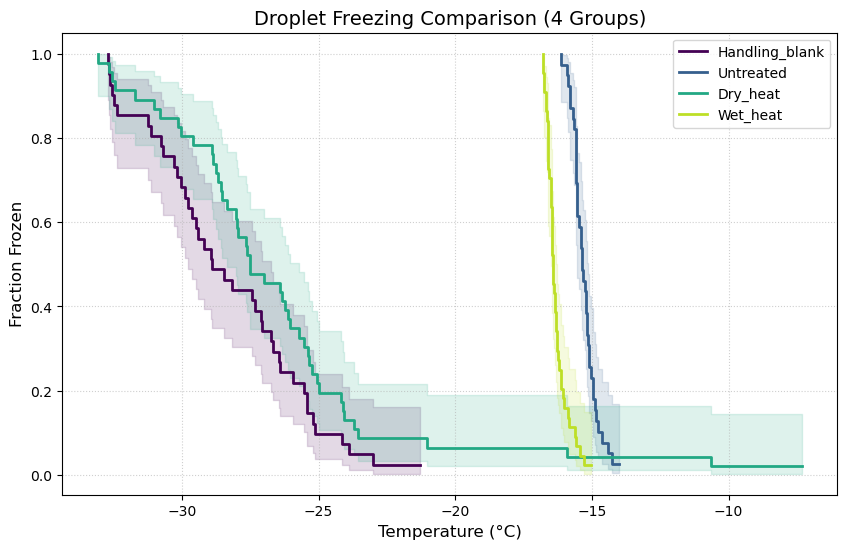

In [18]:
#inline plot properties
plt.figure(figsize=(10, 6), dpi=100)

num_groups = len(valid_groups)
colors = cm.viridis(np.linspace(0, 0.9, num_groups))

for i, group in enumerate(valid_groups):
    subset = final_df_simplified[final_df_simplified['Group'] == group]
    c = colors[i]
    

    plt.step(subset['tf'], subset['fraction_frozen'], 
             where='post', label=group, color=c, linewidth=2)
    

    plt.fill_between(subset['tf'], subset['FF_CI_lower'], subset['FF_CI_upper'], 
                     step='post', color=c, alpha=0.15)

plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Fraction Frozen', fontsize=12)
plt.title(f'Droplet Freezing Comparison ({num_groups} Groups)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)

plt.legend(loc='best', fontsize=10)

plt.show()

In [12]:
import os
print(f"Your files are being saved in: {os.getcwd()}")

Your files are being saved in: C:\Users\eartwh
